# Epic of Sun - Desafio 1
Training  the model.
***

This jupyter notebook trains a UNet for sugarcane identification from satellite images.

It is divided in 6 parts:
* Loading libraries and data
* Separating the dataset in train, validate, and test sets
* Build the model
* Train the model
* Evaluate the model

***

## Loading libraries and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import geopandas as gpd
import rasterio
from rasterio.features import rasterize

import json
import joblib
from pathlib import Path
import os

import tensorflow as tf
from sklearn.model_selection import train_test_split
#import segmentation_models as sm
from tensorflow.keras import layers
from tensorflow.keras.models import Model

import keras_tuner as kt

from sklearn.metrics import (
	classification_report, 
	confusion_matrix, 
	roc_auc_score,
	roc_curve,
	precision_recall_curve, 
    precision_score,
    recall_score,
    f1_score,
	recall_score)

2026-07-22 05:25:43.123987: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784708743.258941  773238 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784708743.296275  773238 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-22 05:25:43.644546: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Get the directory where THIS script is located
base_path = Path.cwd()

In [3]:
# Specify the paths to the mesh and image files
patches_path = base_path / "data" / "processed"

In [4]:
patch_index = pd.read_csv(patches_path / "patch_index.csv" )

print(patch_index.head())
print(len(patch_index))

              scene  patch  row  col                       image_file  \
0  Sertãozinho_test      0    0    0  Sertãozinho_test_patch00000.npy   
1  Sertãozinho_test      1    0   64  Sertãozinho_test_patch00001.npy   
2  Sertãozinho_test      2    0  128  Sertãozinho_test_patch00002.npy   
3  Sertãozinho_test      3    0  192  Sertãozinho_test_patch00003.npy   
4  Sertãozinho_test      4    0  256  Sertãozinho_test_patch00004.npy   

                         mask_file  
0  Sertãozinho_test_patch00000.npy  
1  Sertãozinho_test_patch00001.npy  
2  Sertãozinho_test_patch00002.npy  
3  Sertãozinho_test_patch00003.npy  
4  Sertãozinho_test_patch00004.npy  
1368


## Separating the dataset in train, validate, and test sets

In [5]:
# Random split for one Sentinel scene
# With more scenes, split by scene, not by patch.

# Split the dataset into training and test sets
train_df, test_df = train_test_split(
    patch_index,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# Split the training set into training and validation sets
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42
)

In [6]:
# Function to load the patches individually
def load_dataset(df, image_folder, mask_folder):

    X = []
    Y = []

    for _, row in df.iterrows():

        x = np.load(image_folder / row["image_file"]).astype(np.float32)
        y = np.load(mask_folder / row["mask_file"]).astype(np.float32)

        X.append(x)
        Y.append(y)

    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32)

    Y = Y[..., np.newaxis]

    return X, Y

In [7]:
# Load the datasets

image_folder = patches_path / "images"
mask_folder = patches_path / "masks"

X_train, y_train = load_dataset(train_df, image_folder, mask_folder)
X_val, y_val = load_dataset(val_df, image_folder, mask_folder)
X_test, y_test = load_dataset(test_df, image_folder, mask_folder)

In [8]:
# Print the shapes and data types of the datasets
print("Training set:")
print(X_train.shape)
print(y_train.shape)

print(X_train.dtype)
print(y_train.dtype)

print("\nValidation set:")
print(X_val.shape)
print(y_val.shape)

print(X_val.dtype)
print(y_val.dtype)

print("\nTest set:")
print(X_test.shape)
print(y_test.shape)

print(X_test.dtype)
print(y_test.dtype)

print(np.unique(y_train))

Training set:
(875, 128, 128, 4)
(875, 128, 128, 1)
float32
float32

Validation set:
(219, 128, 128, 4)
(219, 128, 128, 1)
float32
float32

Test set:
(274, 128, 128, 4)
(274, 128, 128, 1)
float32
float32
[0. 1.]


In [9]:
# Print the first row of the patch index
print(patch_index.iloc[0])

scene                        Sertãozinho_test
patch                                       0
row                                         0
col                                         0
image_file    Sertãozinho_test_patch00000.npy
mask_file     Sertãozinho_test_patch00000.npy
Name: 0, dtype: object


## Build the Model

In [10]:
# Convolution block
# Each block performs Conv -> ReLU -> Conv -> ReLU

def conv_block(inputs, filters):

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(inputs)

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        activation="relu"
    )(x)

    return x

In [11]:
# Encoder block
# Each block performs:
#  extracts features
#  saves them for the skip connection
#  downsamples by 2

def encoder_block(inputs, filters):
    x = conv_block(inputs, filters)
    p = layers.MaxPooling2D((2,2))(x)
    return x, p

In [12]:
# Decoder block
# Each block performs:
#  upsamples
#  concatenates the skip connection
#  performs two convolutions

def decoder_block(inputs, skip, filters):

    x = layers.Conv2DTranspose(
        filters,
        2,
        strides=2,
        padding="same"
    )(inputs)
	
    x = layers.Concatenate()([x, skip])

    x = conv_block(x, filters)

    return x

In [13]:
# Function to build the network, compile it, use tunned hyperparameters, and return the model

def build_unet(input_shape=(128,128,4), init_filters=32, lr=1e-3):
    inputs = layers.Input(input_shape)
    
    # Encoder
    s1, p1 = encoder_block(inputs, init_filters)  # 32
    s2, p2 = encoder_block(p1, init_filters * 2)  # 64
    s3, p3 = encoder_block(p2, init_filters * 4)  # 128
    s4, p4 = encoder_block(p3, init_filters * 8)  # 256
    
    # Bottleneck
    b1 = conv_block(p4, init_filters * 16)        # 512
    
    # Decoder
    d1 = decoder_block(b1, s4, init_filters * 8)  # 256
    d2 = decoder_block(d1, s3, init_filters * 4)  # 128
    d3 = decoder_block(d2, s2, init_filters * 2)  # 64
    d4 = decoder_block(d3, s1, init_filters)      # 32
    
    # Output
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d4)
    model = Model(inputs, outputs)
    
    # Unified comilation with the original metrics
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(),
            tf.keras.metrics.Precision(),
            tf.keras.metrics.Recall()
        ]
    )
    return model

In [14]:
# Wrapper function for Keras Tuner to tune hyperparameters

def tune_wrapper(hp):
    # Define the hyperparameters to tune
	# 1. Structural hyperparameters
    hp_filters = hp.Choice("init_filters", values=[8, 16, 32, 64])
    hp_lr = hp.Float("lr", min_value=1e-5, max_value=1e-2, sampling="log")
    
	# 2. Training hyperparameter (Focused on hardware economy)
    hp.Choice("batch_size", values=[8, 16, 32, 64]) 

    # Call original build_unet function with the hyperparameters
    return build_unet(init_filters=hp_filters, lr=hp_lr)

In [15]:
# Hyperparameter search

# Custom Tuner that successfully extracts and applies the batch size
class CustomRandomSearch(kt.RandomSearch):
    def run_trial(self, trial, *args, **kwargs):
        # Safely pull the active hyperparameter sample assigned by Keras Tuner
        hp = trial.hyperparameters
        
        # Inject it into kwargs so tf.keras.Model.fit receives it smoothly
        kwargs['batch_size'] = hp.get('batch_size') 
        return super(CustomRandomSearch, self).run_trial(trial, *args, **kwargs)

# Configuration for low processing
tuner = CustomRandomSearch(
    tune_wrapper,
    objective="val_loss",
    max_trials=30, # Number of different hyperparameter combinations to try
    executions_per_trial=1,
    directory="unet_tuner_results", # Directory to store the results of the hyperparameter search
    project_name="sugarcane_fast",
	overwrite=True # Cleans up older, failed configuration caches
)

# Stop early if the model is not improving to save time
fast_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2)

# Execute the hyperparameter search
tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
	callbacks=[fast_stop]
)

# Extract and print the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best learning rate: {best_hps.get('lr')}")
print(f"Best init_filters:  {best_hps.get('init_filters')}")
print(f"Best batch_size:    {best_hps.get('batch_size')}")

# Save data in JSON file
best_params = {
	"lr": best_hps.get("lr"), 
	"init_filters": best_hps.get("init_filters"),
	"batch_size": int(best_hps.get("batch_size"))
	}

json_path = base_path / "models" / "best_sugarcane_params.json"
with open(json_path, "w") as f:
    json.dump(best_params, f)
print(f"Best hyperparameters saved to {json_path}")

Trial 30 Complete [00h 00m 26s]
val_loss: 0.3372229337692261

Best val_loss So Far: 0.24723973870277405
Total elapsed time: 00h 25m 57s
Best learning rate: 0.00041299887284294384
Best init_filters:  64
Best batch_size:    8
Best hyperparameters saved to /home/fdesmello/Git/spacesugar/models/best_sugarcane_params.json


In [16]:
# Create the model with the best hyperparameters

# Load the best hyperparameters from the JSON file
with open(json_path, "r") as f:
    saved_params = json.load(f)

# Create the model with the best hyperparameters
model = build_unet(
    init_filters=saved_params["init_filters"], 
    lr=saved_params["lr"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 128, 128,  │      2,368 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 128, 128,  │     36,928 │ conv2d_19[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 64, 64,    │    147,584 │ conv2d_21[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ conv2d_22[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 32, 32,    │    295,168 │ max_pooling2d_5[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 32, 32,    │    590,080 │ conv2d_23[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 16, 16,    │          0 │ conv2d_24[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_6[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 16, 16,    │  2,359,808 │ conv2d_25[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 8, 8, 512) │          0 │ conv2d_26[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 8, 8,      │  4,719,616 │ max_pooling2d_7[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 8, 8,      │  9,438,208 │ conv2d_27[0][0]   │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 16, 16,    │  2,097,664 │ conv2d_28[0][0]   │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 16, 16,    │          0 │ conv2d_transpose

 Total params: 31,032,321 (118.38 MB)

 Trainable params: 31,032,321 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# You can just load the model if already trained and not run the random search and best model again
try:
    filename = base_path / "models" / "unet_sugarcane.keras"
    print(filename)
    model = load_model(filename, compile=False)
    print("Loaded saved model.")
except:
    print("No saved model found, proceeding to train a new model.")

/home/fdesmello/Git/spacesugar/models/unet_sugarcane.keras
No saved model found, proceeding to train a new model.


## Train the model

In [19]:
# Checkpoint callback to save the best model based on validation loss
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    base_path / "models" / "unet_sugarcane.keras",
    monitor="val_loss",
    save_best_only=True
)

In [20]:
# Checkpoint callback to save the best model based on validation loss
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [21]:
# Checkpoint callback to reduce learning rate when validation loss plateaus
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

In [22]:
# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=saved_params["batch_size"],
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 26s 172ms/step - binary_accuracy: 0.7720 - loss: 0.4754 - precision_3: 0.7681 - recall_3: 0.9675 - val_binary_accuracy: 0.8774 - val_loss: 0.3245 - val_precision_3: 0.8854 - val_recall_3: 0.9470 - learning_rate: 4.1300e-04
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - binary_accuracy: 0.8652 - loss: 0.3430 - precision_3: 0.8723 - recall_3: 0.9467 - val_binary_accuracy: 0.8676 - val_loss: 0.3403 - val_precision_3: 0.8540 - val_recall_3: 0.9774 - learning_rate: 4.1300e-04
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 108ms/step - binary_accuracy: 0.8838 - loss: 0.3081 - precision_3: 0.8912 - recall_3: 0.9506 - val_binary_accuracy: 0.8801 - val_loss: 0.3124 - val_precision_3: 0.9142 - val_recall_3: 0.9140 - learning_rate: 4.1300e-04
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 13s 118ms/step - binary_accuracy: 0.8892 - loss: 0.2961 - precision_3: 0.8940 - recall_3: 0.9556 - val_binary_accuracy: 0.8861 - val_loss: 0.3000 - val_precision_3: 0.9257

In [23]:
# Save the model
model.save(base_path / "models" / "unet_sugarcane.keras")

## Evaluate the model


Visualization saved as '/home/fdesmello/Git/spacesugar/figures/loss_accuracy.png'


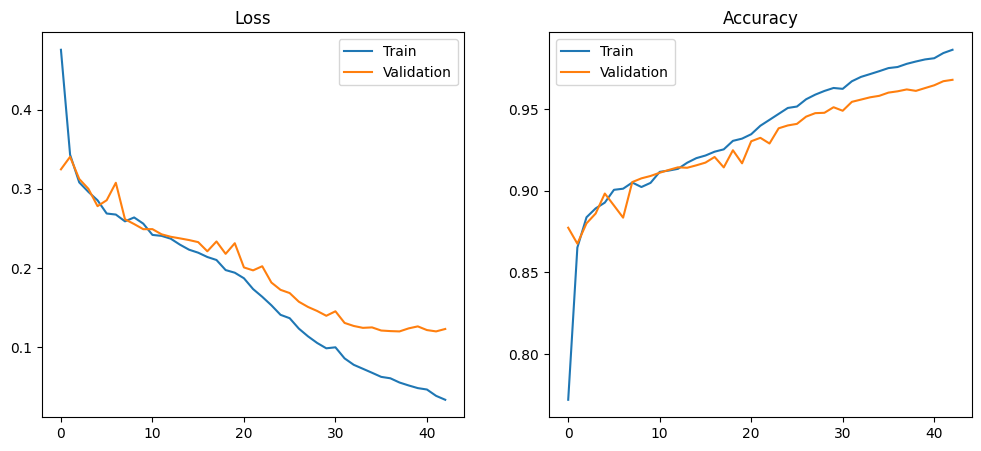

In [24]:
# Plot the learning curves
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["binary_accuracy"], label="Train")
plt.plot(history.history["val_binary_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()

file_path = base_path / "figures" / "loss_accuracy.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"\nVisualization saved as '{file_path}'")

plt.show()

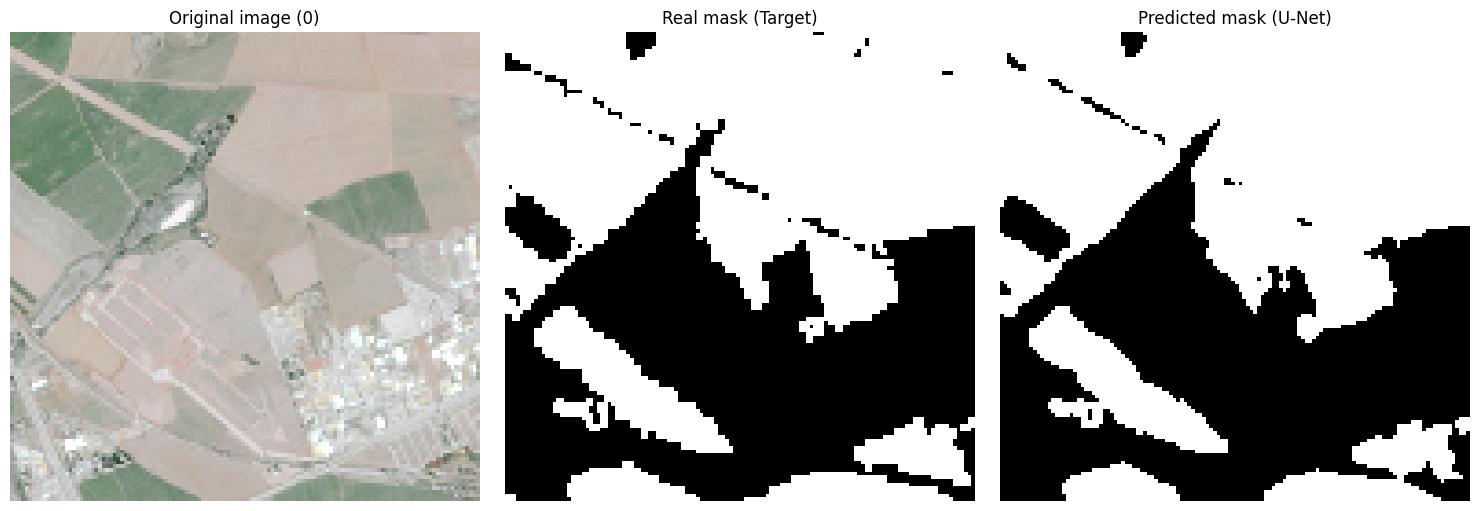

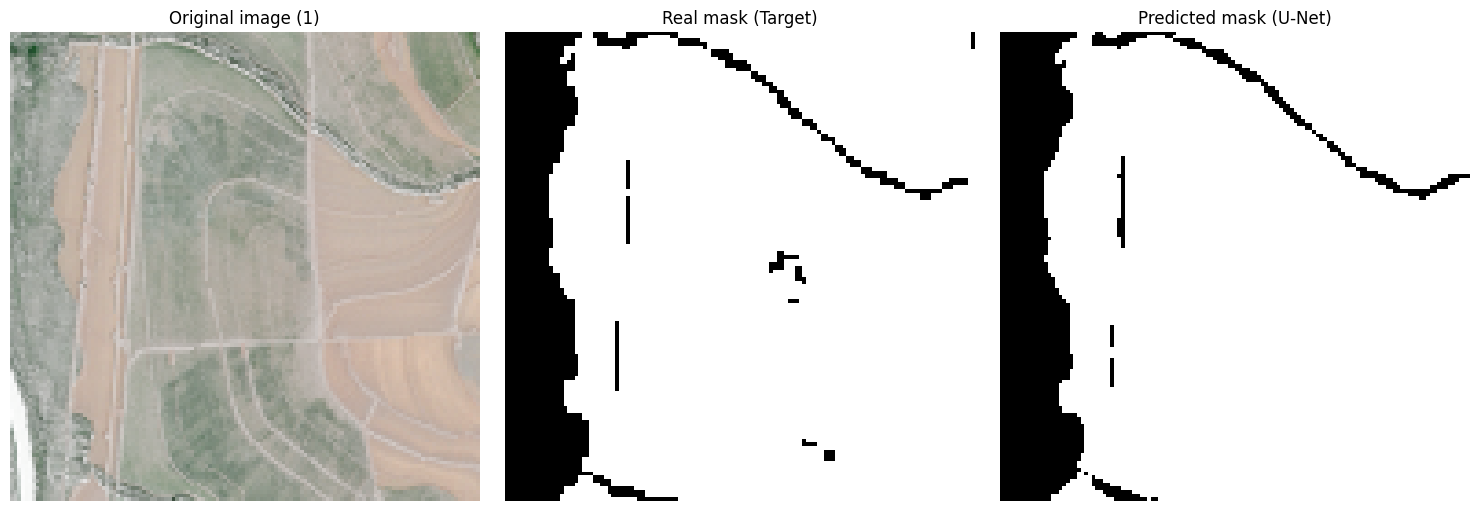

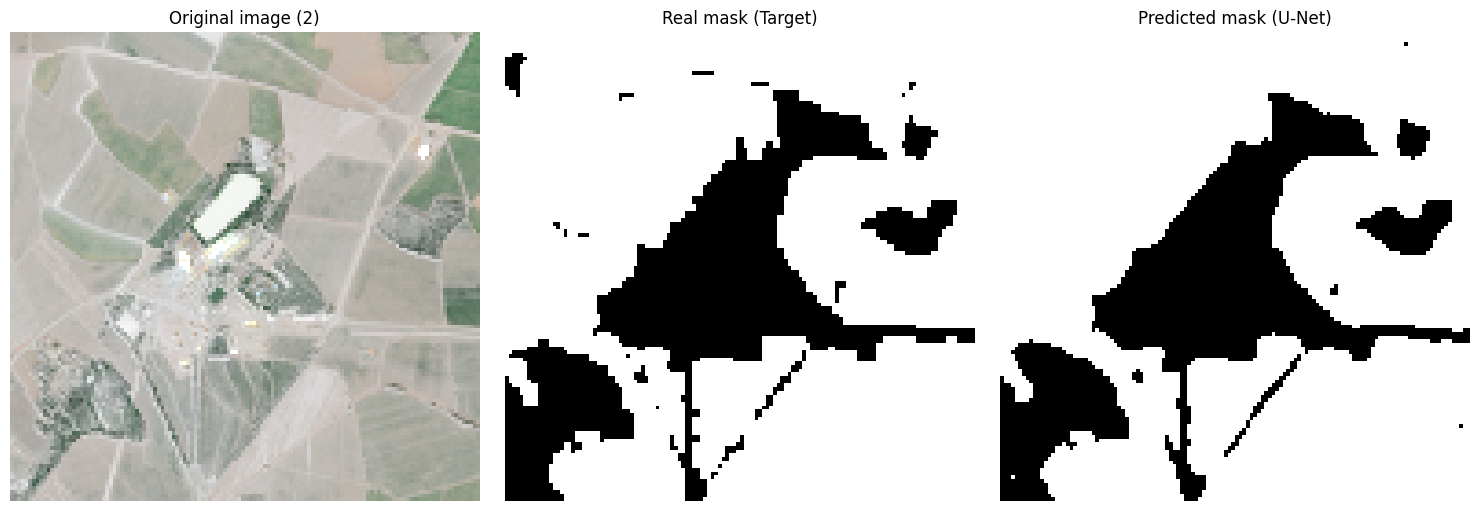

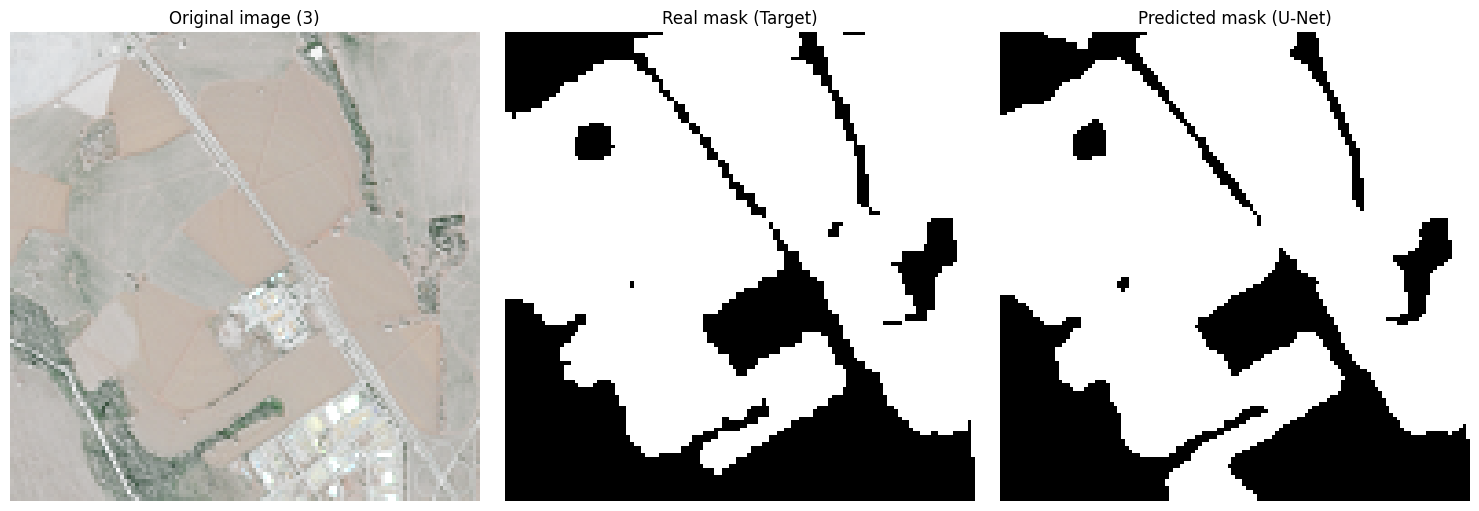

In [25]:
# Visualize the results

max_plots = 4  # Number of images to visualize

all_predictions = [] # List to accumulate all predictions

for i in range(len(X_test)):
    # 1. Extract the single image and make a prediction
    single_img = X_test[i][np.newaxis, ...]
    pred = model.predict(single_img, verbose=0)
    
    # Remove the batch dimension
    pred_squeezed = pred[0]
    all_predictions.append(pred_squeezed) # Save to list for global metrics
    
    # 2. VISUALIZATION SETUP (Only for the first X images)
    if i < max_plots:
        binary_pred = pred_squeezed > 0.5
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))
        
        ax[0].imshow(X_test[i])
        ax[0].set_title(f"Original image ({i})")
        ax[0].axis('off')
        
        ax[1].imshow(y_test[i].squeeze(), cmap='gray')
        ax[1].set_title("Real mask (Target)")
        ax[1].axis('off')
        
        ax[2].imshow(binary_pred.squeeze(), cmap='gray')
        ax[2].set_title("Predicted mask (U-Net)")
        ax[2].axis('off')
        
        file_path = base_path / "figures" / "unet_sugarcane_results_{i}.png"
        plt.savefig(file_path, dpi=300, bbox_inches='tight')

        plt.tight_layout()
        plt.show()

In [26]:
# Metrics Calculation

# 1. Convert all collected predictions into a matching NumPy array
# Shape will become (N, H, W, C) matching y_train
y_pred_all = np.array(all_predictions)

# 2. Transform both entire sets into binary integers
y_pred_bin = (y_pred_all > 0.5).astype(int)
y_true_bin = y_test.astype(int)

# 3. Flatten the entire sets to 1D arrays
y_true_flat = y_true_bin.ravel()
y_pred_flat = y_pred_bin.ravel()

# 3.5. Calculate float probailities
y_true_float = y_test.astype(float).ravel()
y_pred_float = y_pred_all.astype(float).ravel()

# 4. Calculate global metrics
p = precision_score(y_true_flat, y_pred_flat, zero_division=0)
r = recall_score(y_true_flat, y_pred_flat, zero_division=0)
f1 = f1_score(y_true_flat, y_pred_flat, zero_division=0)
roc_auc = roc_auc_score(y_true_flat, y_pred_flat)

print(f"Metrics for the entire dataset:")
print(f"Precision: {p:.4f}")
print(f"Recall: {r:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_true_flat, y_pred_flat)
print("\nConfusion Matrix:")
print(cm)

# 6. Classification Report
print("\nClassification Report:")
print(classification_report(y_true_flat, y_pred_flat, zero_division=0))

Metrics for the entire dataset:
Precision: 0.9681
Recall: 0.9825
F1-Score: 0.9752
ROC AUC Score: 0.9543

Confusion Matrix:
[[1268940  101097]
 [  54707 3064472]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.94   1370037
           1       0.97      0.98      0.98   3119179

    accuracy                           0.97   4489216
   macro avg       0.96      0.95      0.96   4489216
weighted avg       0.97      0.97      0.97   4489216




Visualization saved as '/home/fdesmello/Git/spacesugar/figures/unet_sugarcane_results.png'


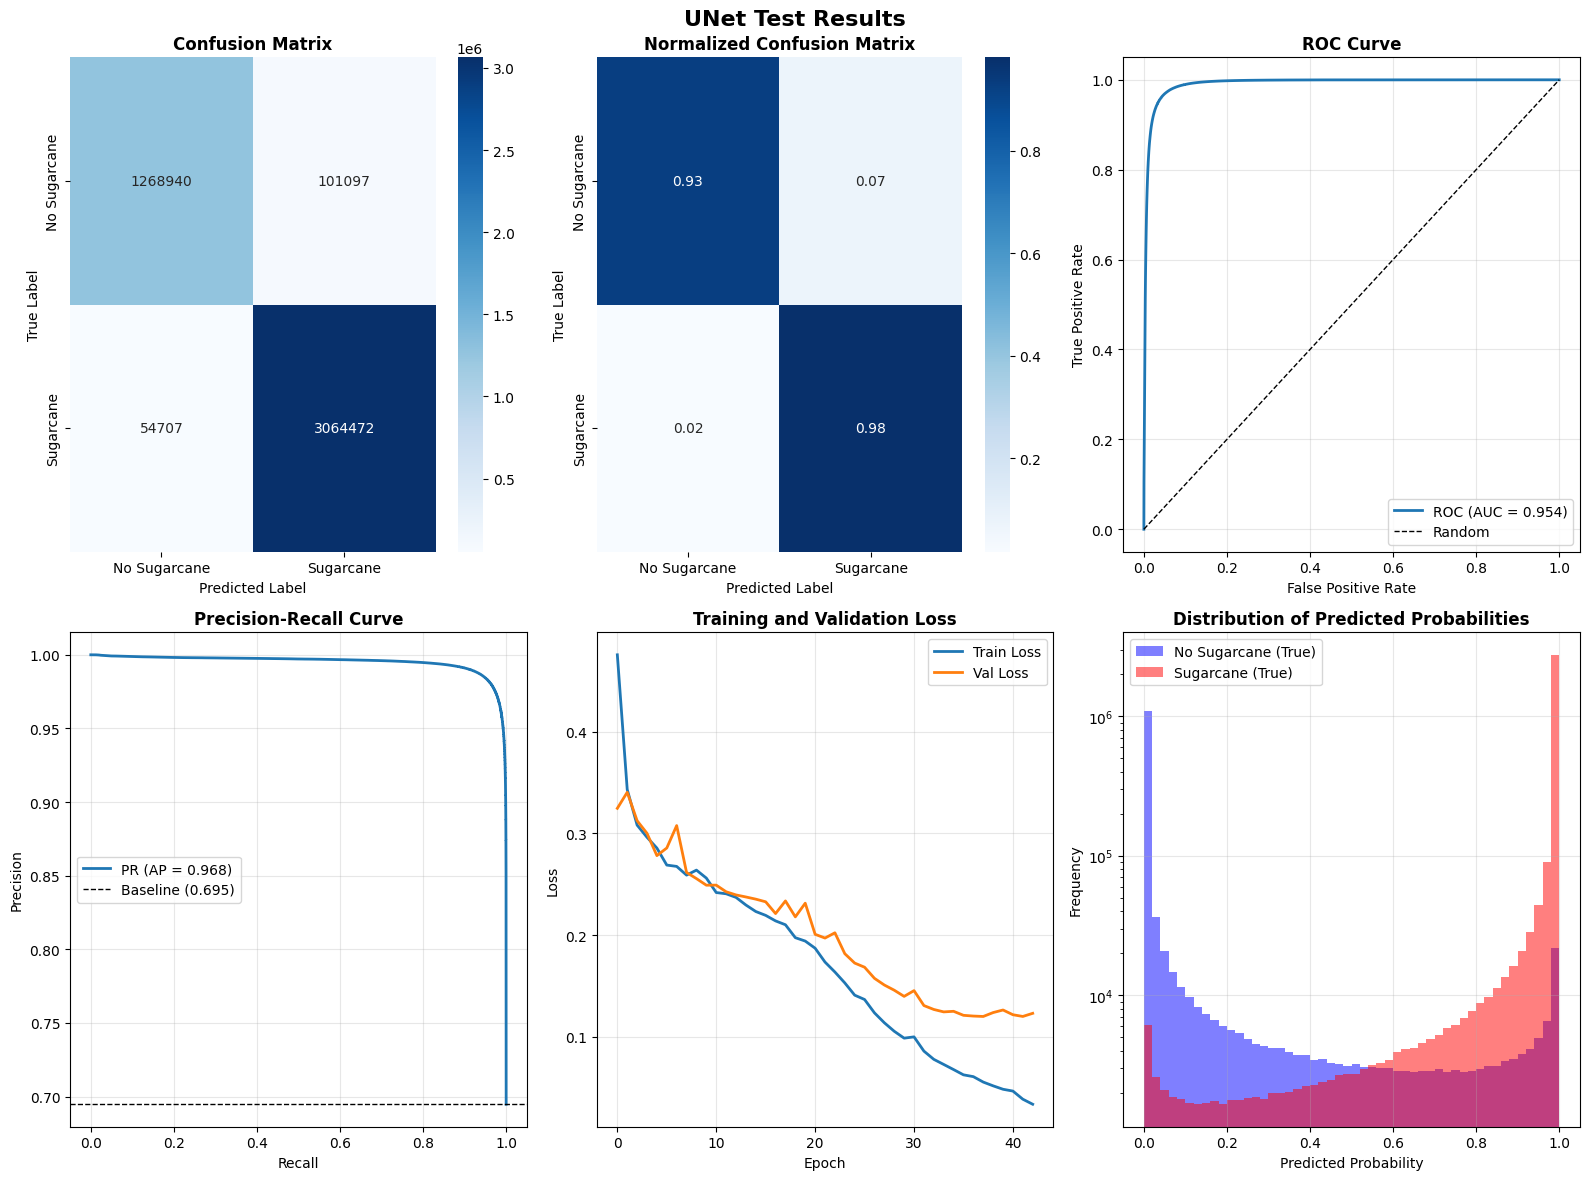

In [27]:
# Visualizations

fig = plt.figure(figsize=(16, 12))
plt.suptitle('UNet Test Results', fontsize=16, fontweight='bold')

class_names = ['No Sugarcane', 'Sugarcane']

# 1. Confusion Matrix
ax1 = plt.subplot(2, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, xticklabels=class_names, yticklabels=class_names)
ax1.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# 2. Normalized Confusion Matrix
cm_norm = pd.DataFrame(cm).apply(lambda x: x/sum(x), axis = 1)
ax2 = plt.subplot(2, 3, 2)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap='Blues', ax=ax2, xticklabels=class_names, yticklabels=class_names)
ax2.set_title('Normalized Confusion Matrix', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

# 3. ROC Curve
if len(np.unique(y_true_float)) > 1:
    ax3 = plt.subplot(2, 3, 3)
    fpr, tpr, _ = roc_curve(y_true_flat, y_pred_float)
    ax3.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
    ax3.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
    ax3.set_xlabel('False Positive Rate')
    ax3.set_ylabel('True Positive Rate')
    ax3.set_title('ROC Curve', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# 4. Precision-Recall Curve
if len(np.unique(y_true_float)) > 1:
    ax4 = plt.subplot(2, 3, 4)
    precision, recall, _ = precision_recall_curve(y_true_flat, y_pred_float)
    ax4.plot(recall, precision, linewidth=2, label=f'PR (AP = {p:.3f})')
    ax4.axhline(y=y_true_flat.mean(), color='k', linestyle='--', linewidth=1, 
                label=f'Baseline ({y_true_flat.mean():.3f})')
    ax4.set_xlabel('Recall')
    ax4.set_ylabel('Precision')
    ax4.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

# 5. Training and Validation Loss
if 'history' in locals():
    hist = history.history
    ax5 = plt.subplot(2, 3, 5)
    ax5.plot(hist['loss'], label='Train Loss', linewidth=2)
    if 'val_loss' in hist:
        ax5.plot(hist['val_loss'], label='Val Loss', linewidth=2)
    ax5.set_xlabel('Epoch')
    ax5.set_ylabel('Loss')
    ax5.set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

# 6. Prediction Probability Distribution
ax6 = plt.subplot(2, 3, 6)
ax6.hist(y_pred_float[y_true_flat == 0], bins=50, alpha=0.5, label='No Sugarcane (True)', color='blue')
ax6.hist(y_pred_float[y_true_flat == 1], bins=50, alpha=0.5, label='Sugarcane (True)', color='red')
ax6.set_xlabel('Predicted Probability')
ax6.set_ylabel('Frequency')
ax6.set_yscale('log')
ax6.set_title('Distribution of Predicted Probabilities', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()

file_path = base_path / "figures" / "unet_sugarcane_results.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"\nVisualization saved as '{file_path}'")

plt.show()